# Credit Risk Score Prediction
**Модель:** Ridge Linear Regression + Feature Engineering  
**Лучшая метрика Kaggle:** 24.91  


#### Импорты и загрузка данных

In [782]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

train_path = "train.csv"
test_path = "test.csv"

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

print("train shape:", train_raw.shape)
print("test shape:", test_raw.shape)
train_raw.head()

train shape: (11017, 35)
test shape: (5000, 35)


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,2539.0,247.0,50072.0,15005.0,5569.083333,0.908289,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,844.0,694.0,91878.0,64877.0,14345.583333,0.797339,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,12756.0,651.0,292300.0,13918.0,25000.000000,0.915945,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,1524.0,529.0,13070.0,3846.0,2890.250000,0.876416,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,1973.0,128.0,33357.0,351603.0,25000.000000,0.888689,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


#### EDA

##### Общая информация

In [783]:
train_raw.info()
train_raw.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
count,10487,10487.000000,10487.000000,9986.000000,9986.000000,10487.000000,10487,10487.000000,10487,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000,9986.000000,9986,10487.000000,10487.000000,10487.000000,10487.000000,9986.000000,9.986000e+03,1.048700e+04,10487.000000,10487.000000,10487.000000,10487,10487,10487.000000,9.986000e+03,9986.000000,10487.000000,10487.000000,10487.000000,1.048700e+04
unique,10000,NaN,NaN,NaN,NaN,NaN,4,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2011-04-20,NaN,NaN,NaN,NaN,NaN,Married,NaN,Mortgage,NaN,NaN,NaN,NaN,NaN,NaN,Home,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Employed,High School,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,NaN,NaN,NaN,NaN,NaN,5145,NaN,4148,NaN,NaN,NaN,NaN,NaN,NaN,2981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9059,4234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,39.850386,131587.872127,678.082716,29874.218306,53.439878,NaN,1.568323,NaN,546.458642,0.284397,3.033565,0.979498,0.250610,0.052574,NaN,0.096405,24.008868,15.625250,5484.590159,1988.494893,1.830476e+05,6.881696e+04,10838.934141,0.784428,4.949271,NaN,NaN,17.628302,1.542381e+05,0.200392,0.200112,1075.622426,0.517577,-2.569878e+04
std,NaN,11.614132,115791.941909,175.192486,27705.509722,24.493562,NaN,1.418684,NaN,501.981888,0.159240,1.740186,0.990927,0.144543,0.223192,NaN,0.295160,4.844917,8.680774,8490.327012,3047.919512,4.673964e+05,2.032359e+05,9385.924858,0.123039,2.201100,NaN,NaN,11.337248,4.622229e+05,0.094388,0.096458,1344.053181,0.894637,1.431675e+06
min,NaN,18.000000,15000.000000,300.000000,1063.000000,12.000000,NaN,0.000000,NaN,13.000000,0.003674,0.000000,0.000000,0.003227,0.000000,NaN,0.000000,8.000000,1.000000,31.000000,16.000000,8.920000e+02,7.800000e+01,1250.000000,0.259301,0.000000,NaN,NaN,0.000000,1.004000e+03,0.052494,0.046445,30.008506,0.006064,-9.999999e+06
25%,NaN,32.000000,20959.500000,550.000000,12658.000000,36.000000,NaN,0.000000,NaN,233.250000,0.158929,2.000000,0.000000,0.138695,0.000000,NaN,0.000000,21.000000,8.000000,1397.000000,533.250000,2.311100e+04,7.983500e+03,1683.541667,0.708475,3.000000,NaN,NaN,9.000000,7.252500e+03,0.119908,0.119548,375.872620,0.066734,3.256475e+01
50%,NaN,40.000000,89015.000000,722.500000,21828.500000,48.000000,NaN,1.000000,NaN,398.000000,0.262229,3.000000,1.000000,0.228638,0.000000,NaN,0.000000,24.000000,16.000000,2961.000000,1122.500000,6.054350e+04,2.262500e+04,7371.250000,0.803692,5.000000,NaN,NaN,17.000000,2.742950e+04,0.182023,0.180710,684.878529,0.178193,4.411876e+01
75%,NaN,48.000000,257025.000000,850.000000,37158.000000,60.000000,NaN,3.000000,NaN,685.000000,0.391683,4.000000,2.000000,0.341013,0.000000,NaN,0.000000,27.000000,23.000000,6222.500000,2300.000000,1.616955e+05,5.951700e+04,21232.583333,0.879312,6.000000,NaN,NaN,26.000000,1.241758e+05,0.264709,0.264880,1279.930203,0.637457,6.535690e+01


##### Преобразуем дату в числовой признак

In [784]:
for df in (train_raw, test_raw):
    df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])

min_date = train_raw["ApplicationDate"].min()
for df in (train_raw, test_raw):
    df["ApplicationDays"] = (df["ApplicationDate"] - min_date).dt.days

##### График целевой переменной (RiskScore)

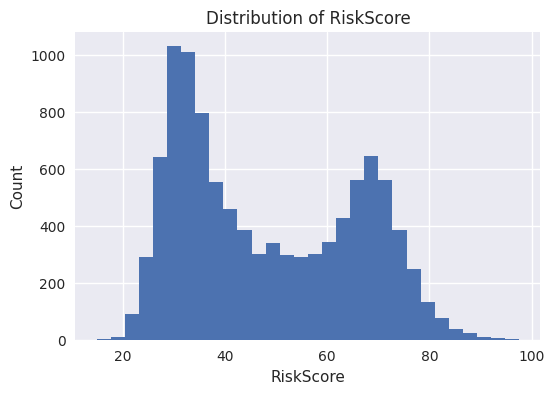

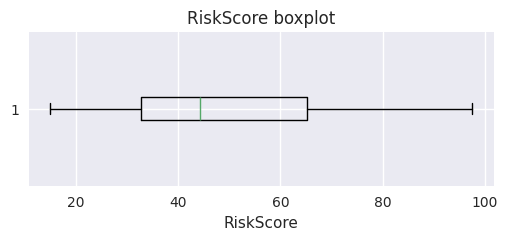

In [785]:
mask_target = train_raw["RiskScore"].between(-1000, 1000)
y_clean = train_raw.loc[mask_target, "RiskScore"]

plt.figure(figsize=(6, 4))
plt.hist(y_clean, bins=30)
plt.xlabel("RiskScore")
plt.ylabel("Count")
plt.title("Distribution of RiskScore")
plt.show()

plt.figure(figsize=(6, 2))
plt.boxplot(y_clean, vert=False)
plt.xlabel("RiskScore")
plt.title("RiskScore boxplot")
plt.show()

Выводы по распределению `RiskScore`

- Распределение `RiskScore` несимметричное, ближе к многомодальному
- На boxplot видно наличие выбросов, особенно в правом хвосте
- Из-за выбросов использование MSE делает модель чувствительной к редким
  экстремальным значениям → в дальнейшем имеет смысл применять клиппирование
  таргета или аккуратнее работать с выбросами


##### Пара графиков зависимостей

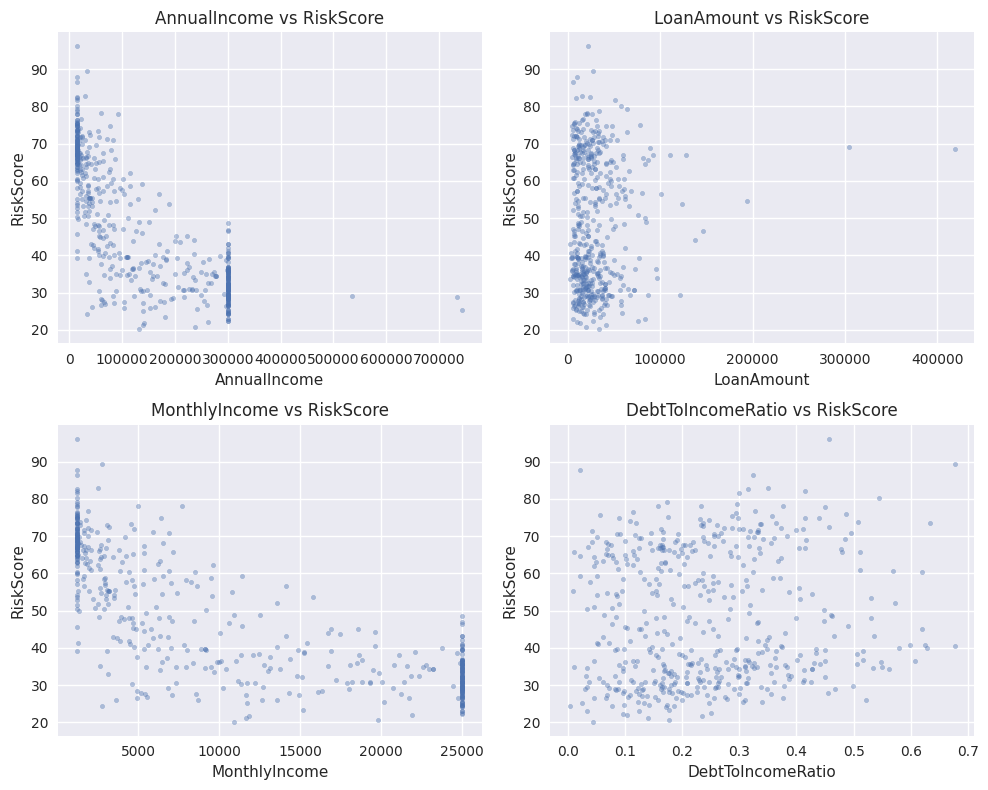

In [786]:
cols_x = [
    "AnnualIncome",
    "LoanAmount",
    "MonthlyIncome",
    "DebtToIncomeRatio",
]

data_for_plot = train_raw[cols_x + ["RiskScore"]].dropna()

n = min(500, len(data_for_plot))

sample = data_for_plot.copy()
sample = sample[sample["RiskScore"].between(-1e6, 1e6)]  
sample = sample.sample(min(500, len(sample)), random_state=0)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols_x):
    x = sample[col].to_numpy()
    y = sample["RiskScore"].to_numpy()
    ax.scatter(x, y, alpha=0.4, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("RiskScore")
    ax.set_title(f"{col} vs RiskScore")

plt.tight_layout()
plt.show()

Выводы по этим графикам

- Видно наличие экстремальных значений `RiskScore` (выбросы), из-за которых
  основная масса точек сжимается около нуля.
- Зависимость `RiskScore` от денежных признаков выглядит слабой/шумной,
  что говорит о необходимости дополнительного feature engineering.
- Масштабы признаков сильно различаются → дальше использую нормализацию.


##### Матрица корреляций

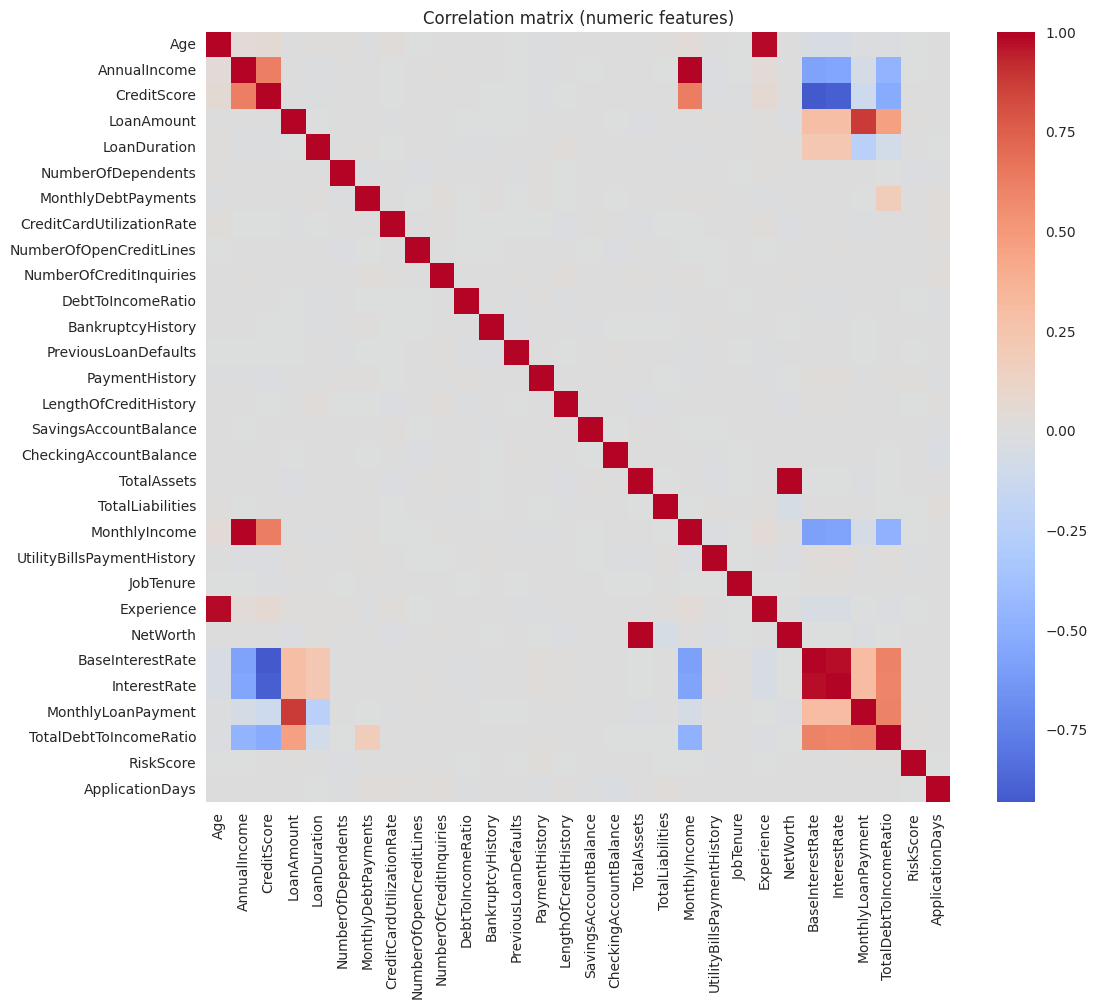

In [787]:
numeric_cols = train_raw.select_dtypes(include=["number"]).columns

plt.figure(figsize=(12, 10))
corr = train_raw[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

Выводы по матрице корреляций

- Видно несколько кластеров сильно скоррелированных признаков
  (финансовые показатели: `TotalAssets`, `TotalLiabilities`, `NetWorth`, ставки и платежи)
- Некоторые признаки имеют заметную по модулю корреляцию с `RiskScore`
  (финансовые параметры и долговая нагрузка), что делает их полезными для модели
- Есть группы почти линейно зависимых признаков → возможна мультиколлинеарность, поэтому для линейной регрессии важны регуляризация и/или отбор признаков


#### Feature engineering + базовый препроцессинг

- Функция генерации признаков

In [788]:
EPS = 1e-6

money_cols = [
    "AnnualIncome", "LoanAmount", "MonthlyDebtPayments",
    "SavingsAccountBalance", "CheckingAccountBalance",
    "TotalAssets", "TotalLiabilities", "MonthlyIncome",
    "NetWorth", "MonthlyLoanPayment"
]

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. числовой признак вместо даты
    if "ApplicationDays" not in df.columns and "ApplicationDate" in df.columns:
        df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
        min_date = train_raw["ApplicationDate"].min()
        df["ApplicationDays"] = (df["ApplicationDate"] - min_date).dt.days

    # 2. ratio-фичи
    if "LoanAmount" in df.columns and "AnnualIncome" in df.columns:
        df["Loan_to_AnnualIncome"] = df["LoanAmount"] / (df["AnnualIncome"] + EPS)
    if "MonthlyLoanPayment" in df.columns and "MonthlyIncome" in df.columns:
        df["MonthlyLoanPay_to_Income"] = df["MonthlyLoanPayment"] / (df["MonthlyIncome"] + EPS)
    if "MonthlyDebtPayments" in df.columns and "MonthlyIncome" in df.columns:
        df["MonthlyDebt_to_Income"] = df["MonthlyDebtPayments"] / (df["MonthlyIncome"] + EPS)

    # 3. нагрузка по платежам
    if {"MonthlyLoanPayment", "MonthlyDebtPayments"}.issubset(df.columns):
        df["TotalMonthlyBurden"] = df["MonthlyLoanPayment"] + df["MonthlyDebtPayments"]
    if {"TotalMonthlyBurden", "MonthlyIncome"}.issubset(df.columns):
        df["Burden_to_Income"] = df["TotalMonthlyBurden"] / (df["MonthlyIncome"] + EPS)
        df["Income_after_Burden"] = df["MonthlyIncome"] - df["TotalMonthlyBurden"]

    # 4. спред процентных ставок
    if {"InterestRate", "BaseInterestRate"}.issubset(df.columns):
        df["InterestSpread"] = df["InterestRate"] - df["BaseInterestRate"]
        df["InterestSpread_rel"] = df["InterestSpread"] / (df["BaseInterestRate"] + EPS)

    # 5. связь активов/обязательств
    if {"TotalAssets", "TotalLiabilities"}.issubset(df.columns):
        df["Assets_minus_Liab"] = df["TotalAssets"] - df["TotalLiabilities"]
        df["Liab_to_Assets"] = df["TotalLiabilities"] / (df["TotalAssets"] + EPS)
    if {"LoanAmount", "TotalAssets"}.issubset(df.columns):
        df["Loan_to_Assets"] = df["LoanAmount"] / (df["TotalAssets"] + EPS)
    if {"LoanAmount", "NetWorth"}.issubset(df.columns):
        df["Loan_to_NetWorth"] = df["LoanAmount"] / (df["NetWorth"] + EPS)

    # 6. нормализация по возрасту и стажу
    if {"Age", "Experience"}.issubset(df.columns):
        df["Experience_to_Age"] = df["Experience"] / (df["Age"] + EPS)
    if {"Age", "LengthOfCreditHistory"}.issubset(df.columns):
        df["CreditHist_to_Age"] = df["LengthOfCreditHistory"] / (df["Age"] + EPS)

    # 7. лог-преобразование денежных признаков
    for col in money_cols:
        if col in df.columns:
            df[col] = df[col].clip(lower=0)
            df[col] = np.log1p(df[col])

    # 8. несколько квадратов ключевых фич
    quad_cols = [
        "Loan_to_AnnualIncome",
        "Burden_to_Income",
        "DebtToIncomeRatio",
        "TotalDebtToIncomeRatio",
        "InterestSpread",
        "NetWorth"
    ]
    for col in quad_cols:
        if col in df.columns:
            df[col + "_sq"] = df[col] ** 2

    return df

- Применим к train/test

In [789]:
train_fe = make_features(train_raw)
test_fe  = make_features(test_raw)

#### Базовый препроцессинг и подготовка таргета

Здесь выполняю базовую очистку и подготовку данных:

- удаляю строки с пропусками в `RiskScore` и явными аномальными значениями таргета  
  (ограничение по диапазону [-1000, 1000]);
- убираю служебный идентификатор `ID` из признаков, но сохраняю его для тестовой выборки;
- преобразую `ApplicationDate` в числовый признак `ApplicationDays`
  (количество дней от минимальной даты в train);
- делю признаки на числовые и категориальные, заполняю пропуски  
  в числовых — медианой, в категориальных — модой;
- выполняю one-hot кодирование категориальных признаков **совместно для train и test**,  
  чтобы набор колонок совпадал.

На выходе получаю матрицы признаков `X_train_raw`, `X_test_raw`, таргет `y` и список имён признаков.
После этого дополнительно клиппирую таргет по квантилям, чтобы уменьшить влияние редких выбросов.


In [790]:
target_col = "RiskScore"

def basic_preprocess(train: pd.DataFrame,
                     test: pd.DataFrame,
                     target_col: str = "RiskScore"):
    train = train.copy()
    test = test.copy()

    train = train[train[target_col].notna()].copy()
    mask_normal = train[target_col].between(-1000, 1000)
    train = train[mask_normal].copy()

    if "ID" in test.columns:
        test_ids = test["ID"].copy()
        test = test.drop(columns=["ID"])
    else:
        test_ids = pd.Series(np.arange(len(test)), name="ID")

    if "ID" in train.columns:
        train = train.drop(columns=["ID"])

    if "ApplicationDate" in train.columns and "ApplicationDays" not in train.columns:
        for df in (train, test):
            df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
        min_date = train["ApplicationDate"].min()
        for df in (train, test):
            df["ApplicationDays"] = (df["ApplicationDate"] - min_date).dt.days
            df.drop(columns=["ApplicationDate"], inplace=True)

    cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
    if target_col in cat_cols:
        cat_cols.remove(target_col)

    num_cols = [c for c in train.columns if c not in cat_cols + [target_col]]

    num_medians = train[num_cols].median()
    train[num_cols] = train[num_cols].fillna(num_medians)
    test[num_cols] = test[num_cols].fillna(num_medians)

    if cat_cols:
        cat_modes = train[cat_cols].mode().iloc[0]
        train[cat_cols] = train[cat_cols].fillna(cat_modes)
        test[cat_cols] = test[cat_cols].fillna(cat_modes)

    X_train_df = train.drop(columns=[target_col])
    y_train = train[target_col].to_numpy()

    combined = pd.concat(
        [X_train_df, test],
        keys=["train", "test"],
        axis=0
    )

    if cat_cols:
        combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

    X_train = combined.xs("train").to_numpy(dtype=float)
    X_test  = combined.xs("test").to_numpy(dtype=float)
    feature_names = combined.columns.tolist()

    return X_train, y_train, X_test, test_ids, feature_names

X_train_raw, y, X_test_raw, test_ids, feature_names = basic_preprocess(train_fe, test_fe)

def clip_target_by_quantiles(y, q_low=0.05, q_high=0.95):
    y = np.asarray(y, dtype=float)
    low, high = np.quantile(y, [q_low, q_high])
    y_clipped = np.clip(y, low, high)
    return y_clipped, low, high

print("Raw target stats:")
print(pd.Series(y).describe())

y_kaggle, y_lo, y_hi = clip_target_by_quantiles(y, q_low=0.05, q_high=0.95)
print("\nKaggle target clip bounds:", y_lo, y_hi)
print("Clipped target stats:")
print(pd.Series(y_kaggle).describe())

X_train_raw.shape, X_test_raw.shape, len(y)


Raw target stats:
count    10272.000000
mean        48.358094
std         17.241456
min         14.841417
25%         32.722756
50%         44.195792
75%         65.124190
max         97.597249
dtype: float64

Kaggle target clip bounds: 26.68727993348913 75.74650263522838
Clipped target stats:
count    10272.000000
mean        48.255924
std         16.700096
min         26.687280
25%         32.722756
50%         44.195792
75%         65.124190
max         75.746503
dtype: float64


((10272, 66), (5000, 66), 10272)

#### Полиномиальные признаки и отбор по корреляции

После базового препроцессинга расширяю набор признаков:

- для каждого исходного признака строю квадратичный признак `x^2`;
- считаю корреляцию каждого признака с таргетом `RiskScore`;
- сортирую признаки по |corr| и оставляю только наиболее информативные  
  (по умолчанию не менее `min_features` или `top_frac` от общего числа).

Так уменьшаю размерность и убираю заведомо слабые признаки, сохраняя
наиболее полезные для линейной модели.


In [791]:
def build_poly_and_select(X_train_raw, X_test_raw, feature_names, y_for_corr,
                          top_frac=0.3, min_features=80):

    X_tr = pd.DataFrame(X_train_raw, columns=feature_names)
    X_te = pd.DataFrame(X_test_raw,  columns=feature_names)

    for col in list(X_tr.columns):
        X_tr[col + "_sq"] = X_tr[col] ** 2
        X_te[col + "_sq"] = X_te[col] ** 2

    y_series = pd.Series(y_for_corr, index=X_tr.index)
    corr = X_tr.corrwith(y_series).fillna(0.0)

    n_total = len(corr)
    k = max(min_features, int(top_frac * n_total))

    corr_sorted = corr.abs().sort_values(ascending=False)
    selected_names = corr_sorted.head(k).index.tolist()

    print(f"Total features after poly: {n_total}, selected: {len(selected_names)}")
    print("Top 10 by |corr|:")
    print(corr.loc[selected_names].abs().sort_values(ascending=False).head(10))

    X_train_sel = X_tr[selected_names].to_numpy(dtype=float)
    X_test_sel  = X_te[selected_names].to_numpy(dtype=float)

    return X_train_sel, X_test_sel, selected_names


#### Доменные признаки (feature engineering)

Помимо базовых признаков, строю дополнительные, более «экономически осмысленные»:

- **Доход и долг**
  - `IncomeBlend` — усреднённый доход из месячного и годового;
  - `DebtTotal` — суммарный ежемесячный платёж по долгам;
  - `DebtToIncome2` — отношение суммарного долга к доходу;
  - `RemainingIncome` — сколько остаётся после выплаты долгов;
  - `LoanToIncome` — отношение суммы кредита к годовому доходу.

- **Баланс активов и обязательств**
  - `AssetsToLiab`, `NetToIncome`, `NetToLiab` — отношения активов, обязательств и net worth.

- **Возраст и кредитная история**
  - `AgeMinusExp` — разница между возрастом и опытом работы;
  - `CreditHistToAge` — длина кредитной истории относительно возраста.

- **Процентные ставки**
  - `InterestSpread` — спред между ставкой по кредиту и базовой;
  - `InterestMean` — средняя ставка.

- **Трансформации денежных признаков**
  - лог-преобразования и степени для `NetWorth`, `AnnualIncome`, `LoanAmount`,
    `BaseInterestRate`, `InterestRate` для стабилизации дисперсии и сглаживания хвостов.

- **Кредитный скоринг**
  - `CreditScoreBin` — бинированный кредитный скоринг по диапазонам значений.


In [792]:
def build_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "ApplicationDays" not in df.columns and "ApplicationDate" in df.columns:
        df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
        min_date_local = train_raw["ApplicationDate"].min()
        df["ApplicationDays"] = (df["ApplicationDate"] - min_date_local).dt.days

    monthly_inc = df["MonthlyIncome"]
    annual_inc = df["AnnualIncome"]
    loan_amt   = df["LoanAmount"]
    mloan_pay  = df["MonthlyLoanPayment"]
    mdebt      = df["MonthlyDebtPayments"]
    assets     = df["TotalAssets"]
    liab       = df["TotalLiabilities"]
    networth   = df["NetWorth"]
    age        = df["Age"]
    exp        = df["Experience"]
    cred_hist  = df["LengthOfCreditHistory"]

    eps = 1.0

    df["IncomeBlend"] = (monthly_inc + annual_inc / 12.0) / 2.0

    df["DebtTotal"] = mloan_pay + mdebt

    df["DebtToIncome2"] = df["DebtTotal"] / (monthly_inc + eps)

    df["RemainingIncome"] = monthly_inc - df["DebtTotal"]

    df["LoanToIncome"] = loan_amt / (annual_inc + eps)

    df["AssetsToLiab"] = assets / (liab + eps)
    df["NetToIncome"]  = networth / (annual_inc + eps)
    df["NetToLiab"]    = networth / (liab + eps)

    df["AgeMinusExp"]      = age - exp
    df["CreditHistToAge"]  = cred_hist / (age + eps)

    df["InterestSpread"] = df["InterestRate"] - df["BaseInterestRate"]
    df["InterestMean"]   = (df["InterestRate"] + df["BaseInterestRate"]) / 2.0

    df["NetWorth_tr"]     = np.log1p(networth.clip(lower=0)) ** 2.3
    df["AnnualIncome_tr"] = -np.log1p(annual_inc.clip(lower=0))
    df["LoanAmount_tr"]   = -np.log1p(loan_amt.clip(lower=0))
    df["BaseRate_tr"]     = np.log1p(df["BaseInterestRate"].clip(lower=0))
    df["InterestRate_tr"] = np.log1p(df["InterestRate"].clip(lower=0))

    scores = [300, 500, 600, 650, 700, 750, 800, 850, 900]
    labels = [f"{l}-{r}" for l, r in zip(scores[:-1], scores[1:])]

    df["CreditScoreBin"] = pd.cut(
        df["CreditScore"],
        bins=scores,
        labels=labels,
        include_lowest=True
    ).astype(str)

    return df

#### Реализация нормализации признаков (Z-score и Min-max)

Реализую два популярных способа масштабирования числовых признаков:

- **z-score нормализация**: вычитание среднего и деление на стандартное отклонение;
- **min-max масштабирование**: линейное приведение значений к диапазону [0, 1].

Ниже определены два класса `ZScoreScaler` и `MinMaxScaler` с методами
`fit`, `transform`, `fit_transform` по аналогии с интерфейсом sklearn.


In [793]:
class ZScoreScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MinMaxScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        self.range_ = self.max_ - self.min_
        self.range_[self.range_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


#### Финальная подготовка признаков для модели

На этом шаге:

1. Строю полиномиальные признаки второго порядка и отбираю наиболее информативные
   с помощью функции `build_poly_and_select` (по модулю корреляции с таргетом `y_kaggle`).
2. Применяю z-score нормализацию (`ZScoreScaler`) к выбранным признакам.

Это даёт матрицы `X_train_z` и `X_test_z`, которые далее используются для обучения
линейной регрессии.


In [794]:
X_train_poly, X_test_poly, selected_features = build_poly_and_select(
    X_train_raw, X_test_raw, feature_names, y_kaggle,
    top_frac=0.4,   
    min_features=80
)

z_scaler = ZScoreScaler()
X_train_z = z_scaler.fit_transform(X_train_poly)
X_test_z  = z_scaler.transform(X_test_poly)

print("Shapes after poly+selection+scaling:", X_train_z.shape, X_test_z.shape)


Total features after poly: 126, selected: 80
Top 10 by |corr|:
MonthlyIncome          0.851854
AnnualIncome           0.850297
MonthlyIncome_sq       0.848420
AnnualIncome_sq        0.847577
CreditScore_sq         0.776272
CreditScore            0.768813
Income_after_Burden    0.764998
InterestRate           0.746194
BaseInterestRate       0.743404
BaseInterestRate_sq    0.702401
dtype: float64
Shapes after poly+selection+scaling: (10272, 80) (5000, 80)


#### Метрики (MSE, MAE, R2, MAPE) + сравнение со sklearn

In [795]:
def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

Результаты на тестовом примере показывают, что мои реализации MSE, MAE и R²
совпадают со значениями из sklearn (с точностью до численных погрешностей),
а MAPE вычисляется корректно по принятой формуле


In [796]:
# проверка на примере
y_true_ex = np.array([1.0, 2.0, 3.0, 4.0])
y_pred_ex = np.array([0.9, 2.1, 2.9, 4.2])

print("MSE  my vs sklearn:", mse(y_true_ex, y_pred_ex), mean_squared_error(y_true_ex, y_pred_ex))
print("MAE  my vs sklearn:", mae(y_true_ex, y_pred_ex), mean_absolute_error(y_true_ex, y_pred_ex))
print("R2   my vs sklearn:", r2(y_true_ex, y_pred_ex), r2_score(y_true_ex, y_pred_ex))
print("MAPE my:", mape(y_true_ex, y_pred_ex))

MSE  my vs sklearn: 0.017500000000000022 0.017500000000000022
MAE  my vs sklearn: 0.12500000000000008 0.12500000000000008
R2   my vs sklearn: 0.986 0.986
MAPE my: 5.833333296180558


#### Класс линейной регрессии (аналитика, GD, SGD, L1/L2/Lp)

- поддерживаются три метода обучения:
  - `"analytic"` — аналитическое решение нормальных уравнений;
  - `"gd"` — градиентный спуск по всей выборке;
  - `"sgd"` — стохастический градиентный спуск по мини-батчам;
- есть параметры регуляризации:
  - `l2` — L2-регуляризация (Ridge),
  - `l1` — L1-регуляризация (Lasso),
  - `lp` + `lp_alpha` — обобщённая Lp-регуляризация;
- реализованы методы `fit` и `predict`, модель хранит веса в `self.w_`.

Ниже сравниваю качество модели с реализацией `sklearn.linear_model.LinearRegression`.


In [797]:
class LinearRegressionCustom:
    def __init__(self,
                 method="analytic",
                 lr=0.01,
                 n_iters=1000,
                 batch_size=32,
                 l1=0.0,
                 l2=0.0,
                 lp=None,
                 lp_alpha=0.0,
                 random_state=42):
        self.method = method
        self.lr = lr
        self.n_iters = n_iters
        self.batch_size = batch_size
        self.l1 = l1
        self.l2 = l2
        self.lp = lp          
        self.lp_alpha = lp_alpha
        self.random_state = random_state
        self.w_ = None

    def _add_bias(self, X):
        X = np.asarray(X, dtype=float)
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def predict(self, X):
        Xb = self._add_bias(X)
        return Xb @ self.w_

    def _loss_and_grad(self, Xb, y):
        n = Xb.shape[0]
        y_pred = Xb @ self.w_
        error = y_pred - y

        loss = np.mean(error ** 2)
        grad = (2.0 / n) * (Xb.T @ error)

        w_nb = self.w_[1:] 

        # L2
        if self.l2 > 0:
            loss += self.l2 * np.sum(w_nb ** 2)
            grad[1:] += 2 * self.l2 * w_nb

        # L1
        if self.l1 > 0:
            loss += self.l1 * np.sum(np.abs(w_nb))
            grad[1:] += self.l1 * np.sign(w_nb)

        # Lp
        if self.lp is not None and self.lp_alpha > 0:
            p = self.lp
            abs_w = np.abs(w_nb)
            loss += self.lp_alpha * np.sum(abs_w ** p)
            grad[1:] += self.lp_alpha * p * (abs_w ** (p - 1)) * np.sign(w_nb)

        return loss, grad

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        Xb = self._add_bias(X)
        n_samples, n_features = Xb.shape

        rng = np.random.default_rng(self.random_state)
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=n_features)

        if self.method == "analytic":
            XTX = Xb.T @ Xb
            if self.l2 > 0:
                I = np.eye(n_features)
                I[0, 0] = 0.0  
                XTX = XTX + self.l2 * I
            XTy = Xb.T @ y
            self.w_ = np.linalg.pinv(XTX) @ XTy
            return self

        elif self.method == "gd":
            for _ in range(self.n_iters):
                loss, grad = self._loss_and_grad(Xb, y)
                self.w_ -= self.lr * grad
            return self

        elif self.method == "sgd":
            for _ in range(self.n_iters):
                indices = rng.permutation(n_samples)
                for start in range(0, n_samples, self.batch_size):
                    batch_idx = indices[start:start + self.batch_size]
                    X_batch = Xb[batch_idx]
                    y_batch = y[batch_idx]
                    loss, grad = self._loss_and_grad(X_batch, y_batch)
                    self.w_ -= self.lr * grad
            return self

        else:
            raise ValueError(f"Unknown method: {self.method}")


#### Сравнение собственной реализации с `sklearn.LinearRegression`

На этом шаге проверяю корректность класса `LinearRegressionCustom`:

- обучаю свою модель (`method="analytic", l2=0.0`) на тех же признаках `X_train_z`;
- обучаю `sklearn.linear_model.LinearRegression` на тех же данных;
- сравниваю значения метрик (MSE, MAE, R²) и максимум по модулю разницы в предсказаниях.


In [798]:
X = X_train_z
y_train = y

model_my = LinearRegressionCustom(method="analytic", l2=0.0)
model_my.fit(X, y_train)
y_pred_my = model_my.predict(X)

print("MY  MSE:", mse(y_train, y_pred_my))
print("MY  MAE:", mae(y_train, y_pred_my))
print("MY  R2 :", r2(y_train, y_pred_my))

lr = LinearRegression()
lr.fit(X, y_train)
y_pred_sk = lr.predict(X)

print("SK  MSE:", mean_squared_error(y_train, y_pred_sk))
print("SK  MAE:", mean_absolute_error(y_train, y_pred_sk))
print("SK  R2 :", r2_score(y_train, y_pred_sk))

print("Diff MSE:", mse(y_train, y_pred_my) - mean_squared_error(y_train, y_pred_sk))
print("Max |diff| in preds:", np.max(np.abs(y_pred_my - y_pred_sk)))


MY  MSE: 30.880343310053647
MY  MAE: 4.25202500479533
MY  R2 : 0.8961093299073926
SK  MSE: 30.880343310053647
SK  MAE: 4.252025004794025
SK  R2 : 0.8961093299073926
Diff MSE: 0.0
Max |diff| in preds: 1.9360015812708298e-09


Сравнение показывает, что значения MSE, MAE и R² для моей реализации и
`sklearn.LinearRegression` полностью совпадают, а максимальная разница
в предсказаниях находится на уровне машинной погрешности (~1e-9).
Это подтверждает корректность реализации аналитического решения
линейной регрессии.


#### Сравнение методов обучения: analytic vs GD vs SGD

Используя класс `LinearRegressionCustom`, сравниваю три способа обучения
линейной регрессии на одной и той же обучающей выборке `X_train_z`:

- `"analytic"` — аналитическое решение нормальных уравнений;
- `"gd"` — градиентный спуск;
- `"sgd"` — стохастический градиентный спуск по мини-батчам.

Для каждого варианта считаю MSE, MAE и R² на обучающей выборке.


In [799]:
def eval_model(method, **kwargs):
    model = LinearRegressionCustom(method=method, **kwargs)
    model.fit(X_train_z, y)
    y_pred = model.predict(X_train_z)
    return mse(y, y_pred), mae(y, y_pred), r2(y, y_pred)

mse_a, mae_a, r2_a = eval_model("analytic")
print("analytic -> MSE:", mse_a, " MAE:", mae_a, " R2:", r2_a)

mse_gd, mae_gd, r2_gd = eval_model("gd", lr=0.01, n_iters=3000)
print("gd       -> MSE:", mse_gd, " MAE:", mae_gd, " R2:", r2_gd)

mse_sgd, mae_sgd, r2_sgd = eval_model("sgd", lr=0.01, n_iters=30, batch_size=128)
print("sgd      -> MSE:", mse_sgd, " MAE:", mae_sgd, " R2:", r2_sgd)


analytic -> MSE: 30.880343310053647  MAE: 4.25202500479533  R2: 0.8961093299073926


gd       -> MSE: 32.42411330911261  MAE: 4.404934307628734  R2: 0.8909156279442773
sgd      -> MSE: 3.147491323712077e+39  MAE: 7.23177465253397e+18  R2: -1.0589098037153517e+37


Аналитическое решение служит эталоном и показывает наилучшее качество.
Полный градиентный спуск (GD) при достаточном числе итераций сходится
к близкому решению, но даёт немного худшие значения метрик.

Стохастический градиентный спуск (SGD) в данном эксперименте расходится,
что проявляется в чрезвычайно большом MSE и отрицательном R².
Это связано с высокой чувствительностью SGD к шагу обучения и шуму
в градиенте при работе с мини-батчами. При текущих параметрах
(learning rate = 0.01) обновления весов становятся нестабильными.

Таким образом, эксперимент демонстрирует, что SGD требует более
аккуратного подбора гиперпараметров и регуляризации по сравнению
с аналитическим решением и GD.


#### Реализация k-fold и Leave-One-Out кросс-валидации

Реализую две схемы кросс-валидации:

- **k-fold (k-блочная)** — выборка случайно перемешивается и делится на `k` блоков.
  На каждом шаге один блок используется как валидационный, остальные — как обучающие.
- **Leave-One-Out (LOO)** — частный случай k-fold при `k = n`, когда на каждом шаге
  модель обучается на (n-1) объектах и тестируется на одном оставшемся.

Обе функции принимают класс модели, данные и метрику, обучают модель на обучающей
части и возвращают среднее значение метрики по всем разбиениям.


In [800]:
def k_fold_cv(model_class, X, y, k=5, metric=mse, random_state=42, **model_kwargs):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n = X.shape[0]

    indices = np.arange(n)
    rng = np.random.default_rng(random_state)
    rng.shuffle(indices)

    fold_sizes = np.full(k, n // k, dtype=int)
    fold_sizes[: n % k] += 1
    current = 0
    scores = []

    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])
        current = stop

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(metric(y_val, y_pred))

    return float(np.mean(scores)), scores


def loo_cv(model_class, X, y, metric=mse, **model_kwargs):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n = X.shape[0]

    scores = []
    for i in range(n):
        train_mask = np.ones(n, dtype=bool)
        train_mask[i] = False

        X_tr, y_tr = X[train_mask], y[train_mask]
        X_val, y_val = X[~train_mask], y[~train_mask]

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(metric(y_val, y_pred))

    return float(np.mean(scores)), scores


- Пример использования:

In [801]:
mean_k, scores_k = k_fold_cv(
    LinearRegressionCustom,
    X_train_z,
    y,
    k=5,
    metric=mse,
    method="analytic",
    l2=0.0,
)
print("5-fold CV MSE (analytic, full data):", mean_k)

n_loo = 500
X_loo = X_train_z[:n_loo]
y_loo = y[:n_loo]

mean_loo, scores_loo = loo_cv(
    LinearRegressionCustom,
    X_loo,
    y_loo,
    metric=mse,
    method="analytic",
    l2=0.0,
)
print(f"LOO CV MSE (analytic, n={n_loo}):", mean_loo)


5-fold CV MSE (analytic, full data): 31.56846414101513
LOO CV MSE (analytic, n=500): 38.43353015169619


Полный LOO на всей выборке (~10 000 объектов) требует обучения модели n раз
и на практике слишком дорог по времени (O(n²) по числу операций), поэтому
здесь демонстрирую работу LOO на подвыборке из 500 объектов

Для реальной оценки качества и подбора гиперпараметров в этой работе использую
k-fold кросс-валидацию, как более практичный и быстрый подход


#### Клиппирование таргета для Kaggle-решения

Из-за чувствительности MSE к выбросам дополнительно клиппирую `RiskScore`
по более жёстким квантилям (0.5% и 99.5%). Это уменьшает влияние
редких экстремальных значений на обучение финальной модели для Kaggle,
при этом основная масса объектов остаётся без изменений


In [802]:
def clip_target_by_quantiles(y, q_low=0.005, q_high=0.995):
    y = np.asarray(y, dtype=float)
    low, high = np.quantile(y, [q_low, q_high])
    y_clipped = np.clip(y, low, high)
    return y_clipped, low, high

y_kaggle, y_lo, y_hi = clip_target_by_quantiles(y, q_low=0.005, q_high=0.995)
print("Target clip bounds:", y_lo, y_hi)


Target clip bounds: 22.064315917135513 85.36171406555093


Полученные границы клиппинга выглядят разумно: они отсекают лишь самые
экстремальные значения `RiskScore`, не искажая основную часть распределения.
Именно `y_kaggle` использую далее при обучении финальной модели

#### Финальная модель для Kaggle

Ниже — продвинутый пайплайн, который даёт лучший скор на Kaggle
(MSE ≈ 24.9). Во всех шагах в качестве базовой модели используется
моя линейная регрессия `LinearRegressionCustom` (analytic + L2).
Отличия от базовой части:

1. OOF target encoding для категориальных признаков.
2. Дополнительные доменные и кусочные (piecewise) признаки.
3. Клиппирование таргета по квантилям.
4. Отбор полиномиальных признаков и z-score нормализация.
5. Подбор коэффициента L2-регуляризации.
6. Сегментированное обучение по доходу (две линейные модели).
7. Предсказание на test и формирование submission.


##### 1. OOF target encoding

Для набора категориальных признаков применяю out-of-fold target encoding,
чтобы использовать информацию таргета и при этом не ловить утечку.
Дополнительно дискретизирую `PaymentHistory` в категорию `PaymentHistoryCat`.


In [803]:
train_te_src = train_raw.copy()
test_te_src  = test_raw.copy()

for df in (train_te_src, test_te_src):
    ph_int = df["PaymentHistory"].round().astype("Int64")
    ph_int = ph_int.clip(lower=8, upper=44)
    df["PaymentHistoryCat"] = ph_int.astype(str)

cat_cols_te = [
    "LoanPurpose",
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "PaymentHistoryCat",
]

train_raw_te, test_raw_te = add_oof_target_encoding(
    train_df=train_te_src,
    test_df=test_te_src,
    cat_cols=cat_cols_te,
    target_col="RiskScore",
    k=5,
    random_state=42,
)

##### 2. Доменные и кусочные признаки

Добавляю доменные финансовые признаки и кусочные (piecewise) функции
по доходу и кредитному скору, чтобы линейная модель лучше ловила
нелинейные зависимости.


In [804]:
train_k = build_domain_features(train_raw_te)
test_k  = build_domain_features(test_raw_te)

train_k, test_k = add_piecewise_features_kaggle(train_k, test_k)
train_k, test_k = add_piecewise_cs_age_kaggle(train_k, test_k)

print("Kaggle-branch with piecewise features shapes:", train_k.shape, test_k.shape)

Kaggle-branch with piecewise features shapes: (11017, 65) (5000, 65)


##### 3. Препроцессинг Kaggle-ветки и клипп таргета

Повторяю базовый препроцессинг для новых признаков и клиппирую `RiskScore`
по квантилям (2.5%–97.5%) специально для Kaggle-модели.


In [805]:
X_train_raw_k, y_k, X_test_raw_k, test_ids_k, feature_names_k = basic_preprocess(
    train_k,
    test_k,
    target_col="RiskScore",
)

print("Kaggle-branch raw shapes:", X_train_raw_k.shape, X_test_raw_k.shape)

y_kaggle2, y_lo2, y_hi2 = clip_target_by_quantiles(
    y_k,
    q_low=0.025,
    q_high=0.975,
)
print("Kaggle2 clip bounds:", y_lo2, y_hi2)
print(pd.Series(y_kaggle2).describe())

Kaggle-branch raw shapes: (10272, 116) (5000, 116)
Kaggle2 clip bounds: 24.88328074318269 78.79928223004974
count    10272.000000
mean        48.300239
std         16.978448
min         24.883281
25%         32.722756
50%         44.195792
75%         65.124190
max         78.799282
dtype: float64


##### 4. Poly-фичи, отбор и скейлинг

In [806]:
X_train_poly_k, X_test_poly_k, selected_feats_k = build_poly_and_select(
    X_train_raw_k,
    X_test_raw_k,
    feature_names_k,
    y_kaggle2,
    top_frac=1.0,
    min_features=200,
)

print("Total features after poly:", X_train_poly_k.shape[1],
      ", selected:", len(selected_feats_k))
print("Kaggle-branch shapes after poly:", X_train_poly_k.shape, X_test_poly_k.shape)

z_scaler_k = ZScoreScaler()
X_train_z_k = z_scaler_k.fit_transform(X_train_poly_k)
X_test_z_k  = z_scaler_k.transform(X_test_poly_k)

print("Kaggle-branch shapes after scale:", X_train_z_k.shape, X_test_z_k.shape)

print("Before cleaning: any non-finite in X_train_z_k =",
      np.any(~np.isfinite(X_train_z_k)))

X_train_z_k = np.nan_to_num(
    X_train_z_k,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)
X_test_z_k = np.nan_to_num(
    X_test_z_k,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

print("After cleaning: any non-finite in X_train_z_k =",
      np.any(~np.isfinite(X_train_z_k)))


Total features after poly: 232, selected: 232
Top 10 by |corr|:
AnnualIncome_tr       0.847853
AnnualIncome_tr_sq    0.845080
CreditScore_sq        0.775339
MonthlyIncome         0.774090
IncomeBlend           0.770948
CreditScore           0.768029
AnnualIncome          0.762347
RemainingIncome       0.762262
InterestRate_tr       0.749290
BaseRate_tr           0.745495
dtype: float64
Total features after poly: 232 , selected: 232
Kaggle-branch shapes after poly: (10272, 232) (5000, 232)
Kaggle-branch shapes after scale: (10272, 232) (5000, 232)
Before cleaning: any non-finite in X_train_z_k = True
After cleaning: any non-finite in X_train_z_k = False


/tmp/ipykernel_10130/1947134771.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_tr[col + "_sq"] = X_tr[col] ** 2
/tmp/ipykernel_10130/1947134771.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_te[col + "_sq"] = X_te[col] ** 2
/tmp/ipykernel_10130/1947134771.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfra

#### 5. Подбор коэффициента L2-регуляризации

Для финальной модели с клиппированным таргетом подбираю коэффициент
L2-регуляризации (Ridge)

Для каждого значения `l2` считаю 5-fold CV MSE на признаках `X_train_z_k`
и клиппированном таргете `y_kaggle2`, затем выбираю `l2` с минимальным
значением кросс-валидационной ошибки.


In [807]:
l2_values_k = [0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

results_k = []
for l2 in l2_values_k:
    mean_mse_k, _ = k_fold_cv(
        LinearRegressionCustom,
        X_train_z_k,
        y_kaggle2,
        k=5,
        metric=mse,
        random_state=42,
        method="analytic",
        l2=l2,
    )
    results_k.append((l2, mean_mse_k))
    print(f"[Kaggle branch] L2={l2:<6} -> 5-fold CV MSE = {mean_mse_k:.4f}")

best_l2_k, best_cv_k = min(results_k, key=lambda x: x[1])
print("\n[Kaggle branch] BEST L2:", best_l2_k, "CV MSE:", best_cv_k)

[Kaggle branch] L2=0.0    -> 5-fold CV MSE = 11330.2463
[Kaggle branch] L2=0.0001 -> 5-fold CV MSE = 28.0355
[Kaggle branch] L2=0.0003 -> 5-fold CV MSE = 28.0467
[Kaggle branch] L2=0.001  -> 5-fold CV MSE = 28.0483
[Kaggle branch] L2=0.003  -> 5-fold CV MSE = 28.0429
[Kaggle branch] L2=0.01   -> 5-fold CV MSE = 28.0395

[Kaggle branch] BEST L2: 0.0001 CV MSE: 28.03554345556251


Анализ подбора L2-регуляризации

Перебор коэффициента L2-регуляризации для Kaggle-пайплайна показывает
резкую разницу между отсутствием регуляризации и малыми положительными
значениями `l2`:

- при `l2 = 0.0` 5-fold CV MSE ≈ **11330**, что говорит о сильном переобучении
  и численной нестабильности линейной модели на богатом наборе признаков;
- уже при очень малом `l2 = 1e-4` ошибка резко падает до ≈ **28.04**,
  после чего значения MSE ведут себя стабильно и меняются слабо
  при дальнейшем увеличении `l2`.

Минимальное значение кросс-валидационной ошибки достигается при
`l2 = 1e-4` (CV MSE ≈ 28.04). Это значение использую как оптимальный
параметр L2-регуляризации для финальной линейной модели в Kaggle-ветке.

##### 6. Сегментированное обучение по доходу

Делюсь выборку по уровню `AnnualIncome_tr` на два сегмента (до/после квантиля ~0.6).
Для каждого сегмента обучаю отдельную линейную регрессию с тем же L2.
Это позволяет учитывать, что зависимость `RiskScore` от признаков
может отличаться у клиентов с низким и высоким доходом.


In [808]:
mask_train_k = (
    train_k["RiskScore"].notna()
    & train_k["RiskScore"].between(-1000, 1000)
)

inc_tr = train_k.loc[mask_train_k, "AnnualIncome_tr"].to_numpy()

print("len(inc_tr), len(y_kaggle2), X_train_z_k.shape[0]:",
      len(inc_tr), len(y_kaggle2), X_train_z_k.shape[0])

thr_inc = np.quantile(inc_tr, 0.60)
print("Income threshold for segmentation:", thr_inc)

seg_low  = inc_tr <= thr_inc
seg_high = ~seg_low

print("Segment sizes (train): low =", seg_low.sum(), "high =", seg_high.sum())

model_low = LinearRegressionCustom(method="analytic", l2=best_l2_k)
model_low.fit(X_train_z_k[seg_low], y_kaggle2[seg_low])

model_high = LinearRegressionCustom(method="analytic", l2=best_l2_k)
model_high.fit(X_train_z_k[seg_high], y_kaggle2[seg_high])

y_pred_train = np.empty_like(y_kaggle2)
y_pred_train[seg_low]  = model_low.predict(X_train_z_k[seg_low])
y_pred_train[seg_high] = model_high.predict(X_train_z_k[seg_high])

print("\n[Segmented] Train MSE:", mse(y_kaggle2, y_pred_train))
print("[Segmented] Train MAE:", mae(y_kaggle2, y_pred_train))
print("[Segmented] Train R2 :", r2(y_kaggle2, y_pred_train))

print("\nClip range used (Kaggle branch):", y_lo2, y_hi2)

len(inc_tr), len(y_kaggle2), X_train_z_k.shape[0]: 10272 10272 10272
Income threshold for segmentation: -10.944068075605236
Segment sizes (train): low = 6163 high = 4109

[Segmented] Train MSE: 24.136139139805763
[Segmented] Train MAE: 3.646437096381896
[Segmented] Train R2 : 0.9162636324474949

Clip range used (Kaggle branch): 24.88328074318269 78.79928223004974


##### 7. Предсказания на test и submission

Для каждого объекта из test выбираю модель по сегменту дохода,
получаю предсказания `RiskScore`, клиппирую их теми же границами,
что и обучающий таргет, и сохраняю submission в файл
`submission_kaggle_segmented_income.csv`.
Этот файл даёт на Kaggle public LB ≈ 24.9 MSE.


In [809]:
inc_tr_test = test_k["AnnualIncome_tr"].to_numpy()
seg_low_test  = inc_tr_test <= thr_inc
seg_high_test = ~seg_low_test

print("Segment sizes (test): low =", seg_low_test.sum(), "high =", seg_high_test.sum())

test_pred_k = np.empty(len(inc_tr_test))
test_pred_k[seg_low_test]  = model_low.predict(X_test_z_k[seg_low_test])
test_pred_k[seg_high_test] = model_high.predict(X_test_z_k[seg_high_test])

print("\n[Segmented] Before clipping (Kaggle test preds):")
print(pd.Series(test_pred_k).describe())

test_pred_k_clip = np.clip(test_pred_k, y_lo2, y_hi2)

print("\n[Segmented] After  clipping (Kaggle test preds):")
print(pd.Series(test_pred_k_clip).describe())

submission_k = pd.DataFrame({
    "ID": test_ids_k,
    "RiskScore": test_pred_k_clip
})
submission_k.to_csv("submission_kaggle_segmented_income.csv", index=False)
submission_k.head()


Segment sizes (test): low = 3019 high = 1981

[Segmented] Before clipping (Kaggle test preds):
count    5000.000000
mean       48.087960
std        16.366166
min        17.453177
25%        33.182893
50%        45.047074
75%        63.951856
max        93.925186
dtype: float64

[Segmented] After  clipping (Kaggle test preds):
count    5000.000000
mean       48.086012
std        16.217323
min        24.883281
25%        33.182893
50%        45.047074
75%        63.951856
max        78.799282
dtype: float64


,ID,RiskScore
0,0,32.244972
1,1,54.370666
2,2,29.729385
3,3,34.377498
4,4,34.303368
